In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/snehajuyal/SALES/SALES/data/cleaned_online_retail.csv")

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [10]:
if 'TotalPrice' not in df.columns:
    df['TotalPrice'] = df['Quantity'] * df['Price']


In [9]:
df['TotalPrice'].sum()

np.float64(16648292.388000002)

In [11]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

In [12]:
monthly_sales = df.groupby('YearMonth')['TotalPrice'].sum()

In [13]:
monthly_sales

YearMonth
2009-12     663272.050
2010-01     531952.902
2010-02     489399.586
2010-03     635996.481
2010-04     560635.022
2010-05     559924.550
2010-06     571459.910
2010-07     562785.900
2010-08     587256.460
2010-09     781033.301
2010-10     964989.780
2010-11    1134879.282
2010-12     859227.370
2011-01     475074.380
2011-02     436546.150
2011-03     579964.610
2011-04     426047.851
2011-05     648251.080
2011-06     608013.160
2011-07     574238.481
2011-08     616368.000
2011-09     931440.372
2011-10     974603.590
2011-11    1132407.740
2011-12     342524.380
Freq: M, Name: TotalPrice, dtype: float64

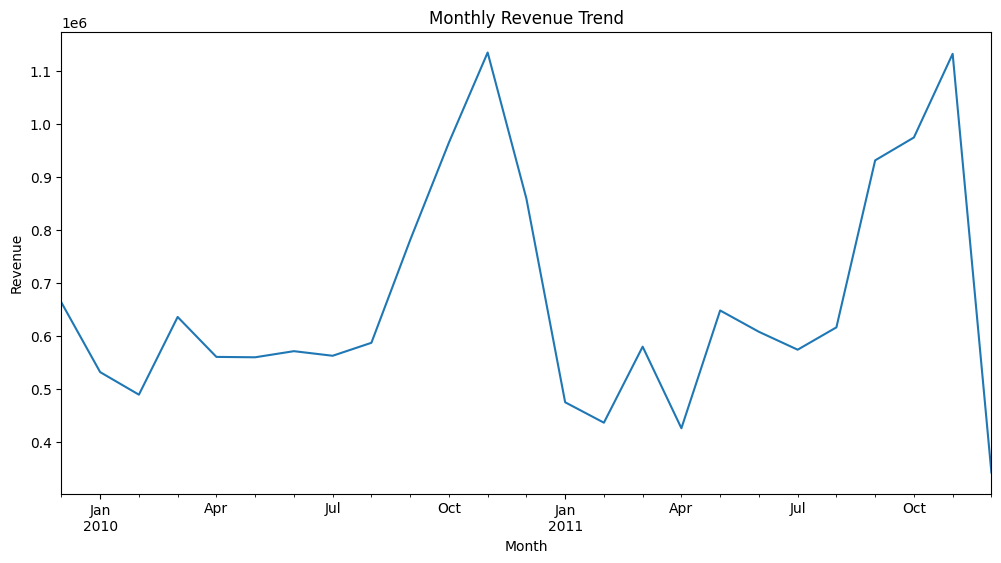

In [14]:
monthly_sales.plot(figsize=(12,6))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [15]:
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

In [16]:
top_products

Description
REGENCY CAKESTAND 3 TIER              269736.70
WHITE HANGING HEART T-LIGHT HOLDER    242700.51
JUMBO BAG RED RETROSPOT               134845.16
ASSORTED COLOUR BIRD ORNAMENT         126354.18
POSTAGE                               112249.10
PARTY BUNTING                         102686.23
PAPER CHAIN KIT 50'S CHRISTMAS         78366.93
CHILLI LIGHTS                          72229.34
BLACK RECORD COVER FRAME               67127.15
JUMBO BAG STRAWBERRY                   64089.41
Name: TotalPrice, dtype: float64

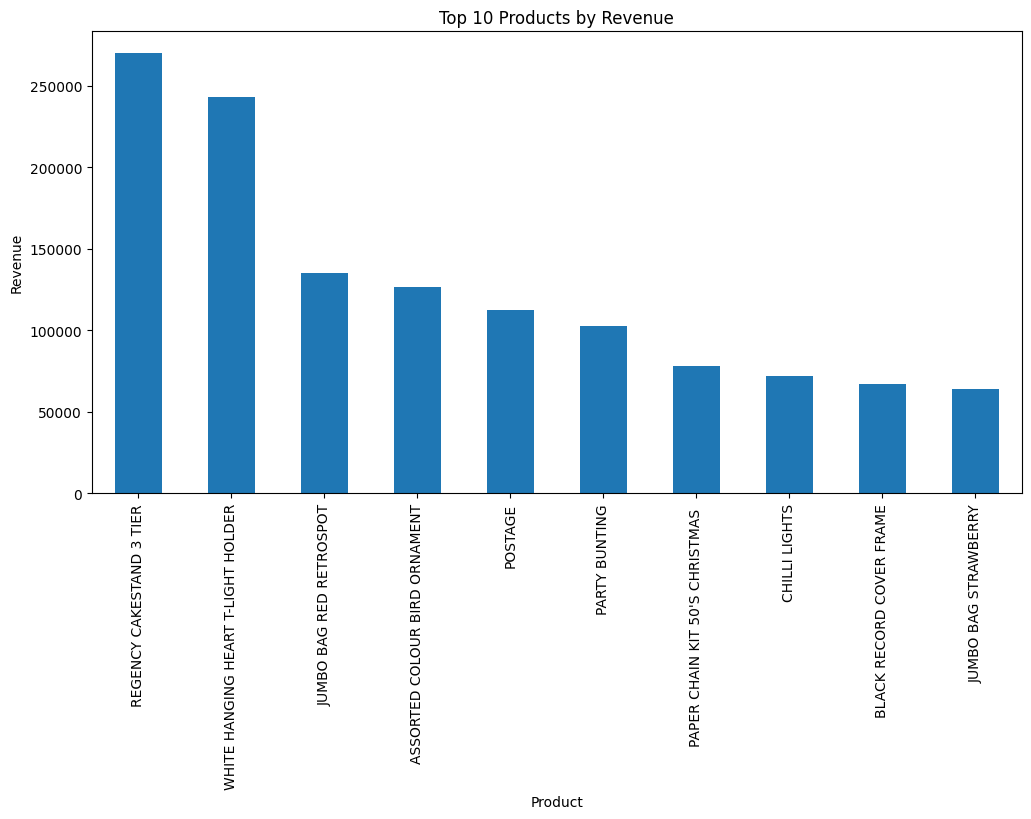

In [17]:
top_products.plot(kind='bar', figsize=(12,6))

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()

In [18]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

In [19]:
country_sales

Country
United Kingdom    1.380642e+07
EIRE              5.785016e+05
Netherlands       5.485249e+05
Germany           4.179886e+05
France            3.265047e+05
Australia         1.671291e+05
Switzerland       9.908281e+04
Spain             9.185948e+04
Sweden            8.745542e+04
Denmark           6.574109e+04
Name: TotalPrice, dtype: float64

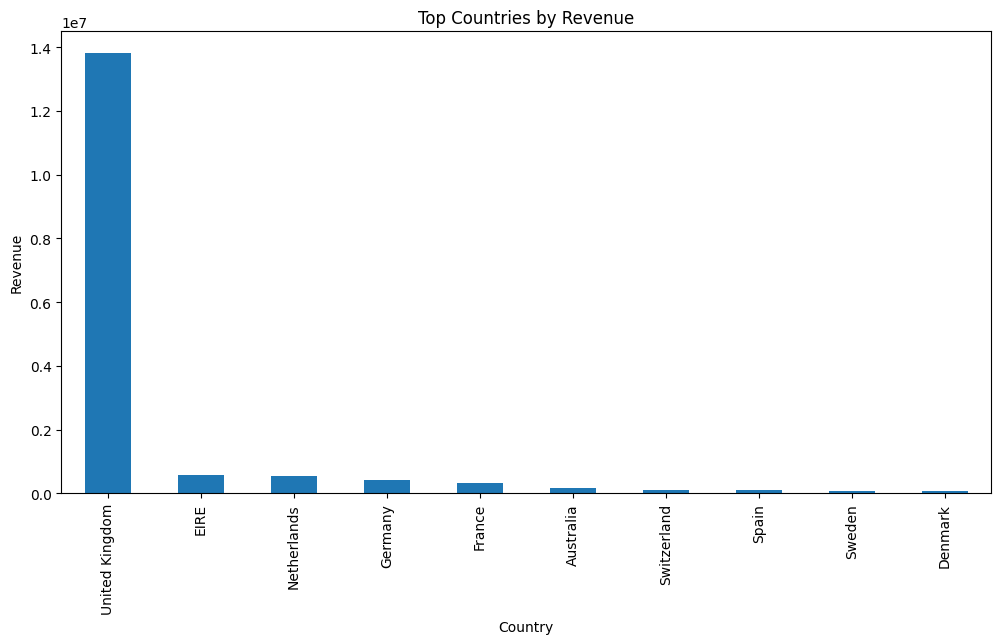

In [20]:
country_sales.plot(kind='bar', figsize=(12,6))

plt.title("Top Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.show()

In [21]:
top_customers = df.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

In [22]:
top_customers

Customer ID
18102.0    598215.22
14646.0    523342.07
14156.0    296564.69
14911.0    270248.53
17450.0    233579.39
13694.0    190825.52
17511.0    171885.98
12415.0    143269.29
16684.0    141502.25
15061.0    136391.48
Name: TotalPrice, dtype: float64

In [23]:
customer_orders = df.groupby('Customer ID')['Invoice'].nunique()

In [24]:
repeat_customers = customer_orders[customer_orders > 1]

In [25]:
len(repeat_customers)

4481

In [26]:
repeat_rate = (len(repeat_customers) / len(customer_orders)) * 100

round(repeat_rate, 2)

75.41

In [27]:
avg_order_value = df.groupby('Invoice')['TotalPrice'].sum().mean()

round(avg_order_value, 2)

np.float64(370.98)

In [28]:
df['Date'] = df['InvoiceDate'].dt.date

In [29]:
daily_sales = df.groupby('Date')['TotalPrice'].sum()

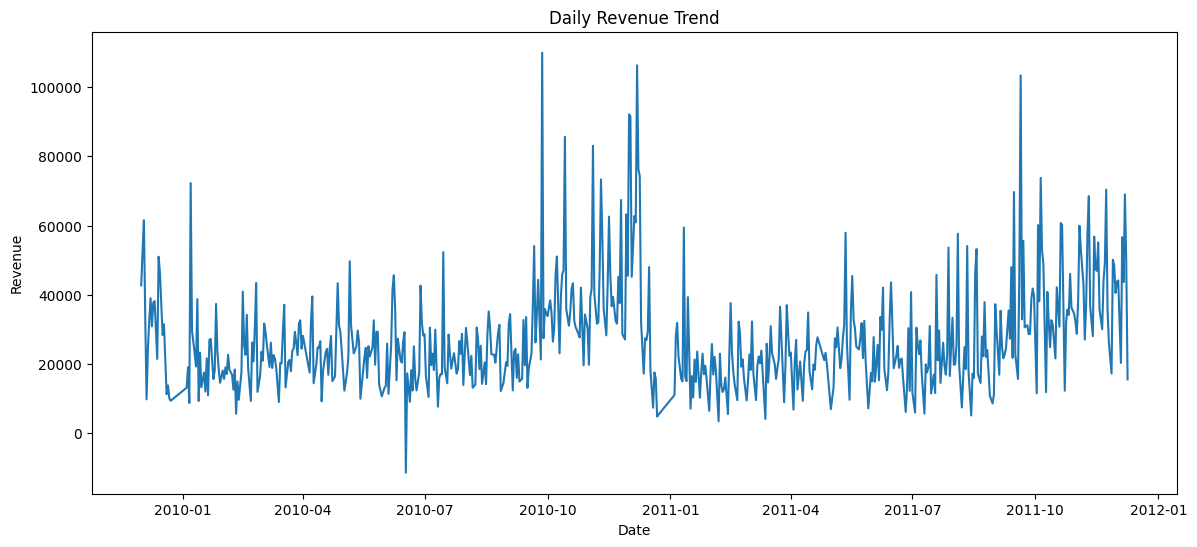

In [30]:
daily_sales.plot(figsize=(14,6))

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()